# Wind Resource Emulator -- from 24 fixed years to a continuous, perturbable wind climate

The pipeline so far samples wind climate from exactly 24 discrete `UniformWeibullSite` objects, one per ERA5 year (2000-2023) -- a fixed, finite set. Here, I replace that with a generative emulator: PCA over the 24-year parameter space, so the Monte Carlo can draw as many plausible wind climates as needed, including deliberately extreme ones, instead of only re-picking among 24 historical years.

This closes future-work item 3 from the benchmark paper (Rodrigues & Moura 2025) -- *"correlation between wind rose sectors and AEP losses"* -- and answers AIM 2's call for "a wide range of possible scenarios", not a fixed sample of 24.

**On the PyWake/DTU side**: the site module has no ensemble/bootstrap/multi-climate class -- `UniformWeibullSite(p_wd, a, k, ti)` is a thin wrapper around `XRSite` (an xarray dataset), one climate per object. That pattern is not changed here -- it is the DTU convention. What changes is only where `p_wd`, `a`, and `k` come from: instead of one of 24 real years, they come from a sampled point in the fitted distribution.

In [ ]:

# ENVIRONMENT CHECK -- run this first. Installs/upgrades this kernel's
# environment to the exact package versions this notebook was tested with.
# ===============================
import importlib.metadata 
import subprocess
import sys

REQUIRED = {
    "numpy": "2.3.2", "scipy": "1.17.1", "matplotlib": "3.10.6", "xarray": "2025.1.0",
    "shapely": "2.1.2", "pyproj": "3.7.0", "openmdao": "3.40.0", "windIO": "2.1.1",
    "py_wake": "2.6.20", "optiwindnet": "0.3.0", "ortools": "9.15.6755",
    "h5py": "3.16.0", "netCDF4": "1.7.4", "openturns": "1.27.post1", "scikit-learn": "1.9.0",
}

def installed(pkg):
    try:
        return importlib.metadata.version(pkg)
    except importlib.metadata.PackageNotFoundError:
        return None

mismatched = {p: v for p, v in REQUIRED.items() if installed(p) != v}

if mismatched:
    print(f"Installing {len(mismatched)} package(s) to the versions this notebook was tested with...")
    for pkg, version in mismatched.items():
        print(f"  {pkg}=={version} ...")
        result = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', f'{pkg}=={version}'],
                                 capture_output=True, text=True)
        if result.returncode != 0:
            print(result.stdout[-2000:])
            print(result.stderr[-2000:])
            raise RuntimeError(
                f"Could not install '{pkg}=={version}' automatically. Install it manually in this "
                f"kernel's environment (`{sys.executable} -m pip install {pkg}=={version}`) and re-run "
                f"this cell.")
    importlib.metadata.invalidate_caches()

print("Environment OK -- all versions match what this notebook was tested with.")

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

sys.path.insert(0, str(Path("..") / ".." / "Project_Monte_Carlo"))
from download_era5_vineyard import load_wind_series, LAT_CENTER, LON_CENTER
from build_pywake_sites import fit_sector_weibull, YEARS, N_SECTORS
from py_wake.site import UniformWeibullSite

ERA5_DIR = Path("..") / ".." / "Project_Monte_Carlo" / "era5_vineyard"
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)
TI = 0.06
SECTOR_DEG = np.linspace(0, 360, N_SECTORS, endpoint=False)

/opt/anaconda3/envs/wesl_jul_31/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. The old way -- 24 fixed sites

Each ERA5 year is reduced to 36 numbers: 12 sectors x (frequency, Weibull A, Weibull k). Stacking the 24 years gives exactly 24 points in a 36-dimensional space -- the entire climate uncertainty the old pipeline could draw from.

In [2]:
rows = []
for year in YEARS:
    path = ERA5_DIR / f"era5_{year}.grib"
    _t, speed, direction = load_wind_series(str(path), LAT_CENTER, LON_CENTER)
    freq, A, k = fit_sector_weibull(speed, direction)
    rows.append(np.concatenate([freq, A, k]))
    print(f"{year}: mean speed {speed.mean():.2f} m/s")

REAL_MATRIX = np.array(rows)  # 24 x 36 (12 freq, 12 A, 12 k)
print(f"\nREAL_MATRIX shape: {REAL_MATRIX.shape}")

Ignoring index file '../../Project_Monte_Carlo/era5_vineyard/era5_2000.grib.5b7b6.idx' incompatible with GRIB file


Ignoring index file '../../Project_Monte_Carlo/era5_vineyard/era5_2001.grib.5b7b6.idx' incompatible with GRIB file


2000: mean speed 9.17 m/s


Ignoring index file '../../Project_Monte_Carlo/era5_vineyard/era5_2002.grib.5b7b6.idx' incompatible with GRIB file


2001: mean speed 8.73 m/s


...

Ignoring index file '../../Project_Monte_Carlo/era5_vineyard/era5_2022.grib.5b7b6.idx' incompatible with GRIB file


2021: mean speed 8.87 m/s


Ignoring index file '../../Project_Monte_Carlo/era5_vineyard/era5_2023.grib.5b7b6.idx' incompatible with GRIB file


2022: mean speed 9.22 m/s


2023: mean speed 8.53 m/s

REAL_MATRIX shape: (24, 36)


## 2. A few real roses

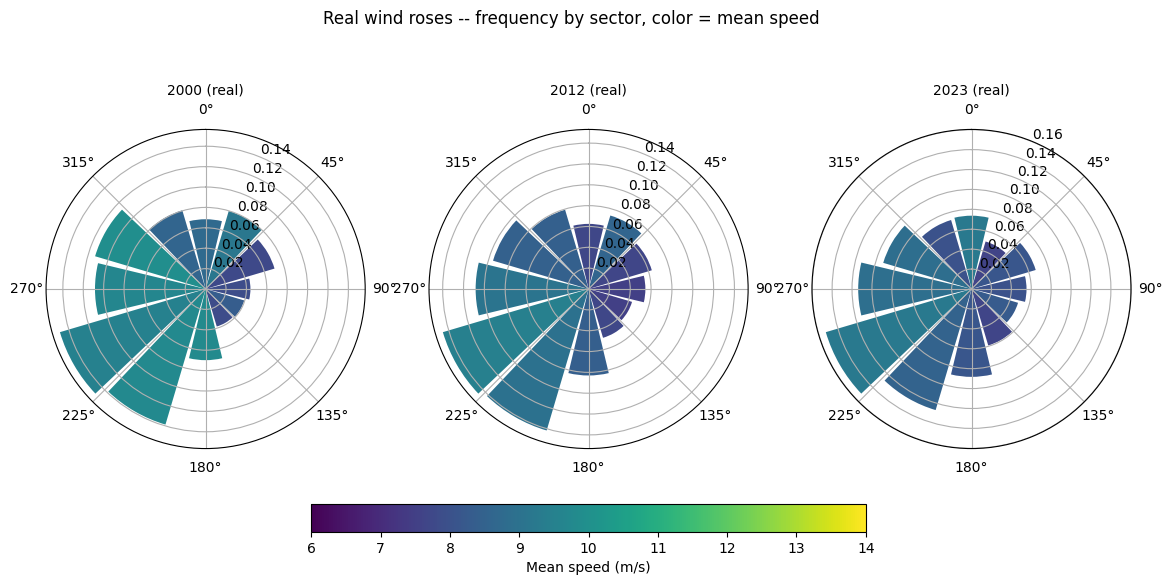

In [3]:
SPEED_VMIN, SPEED_VMAX = 6.0, 14.0  # shared color scale across every rose plot in this notebook

def rose_from_row(row):
    freq, A, k = row[:12], row[12:24], row[24:36]
    mean_speed = A * gamma(1 + 1 / k)
    return freq, mean_speed

def plot_rose(ax, row, title):
    freq, mean_speed = rose_from_row(row)
    theta = np.radians(SECTOR_DEG)
    norm = plt.Normalize(SPEED_VMIN, SPEED_VMAX)
    ax.bar(theta, freq, width=2 * np.pi / N_SECTORS * 0.9, color=plt.cm.viridis(norm(mean_speed)))
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_title(title, fontsize=10)

def add_speed_colorbar(fig, axes):
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(SPEED_VMIN, SPEED_VMAX))
    sm.set_array([])
    fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.06, pad=0.12, label="Mean speed (m/s)")

fig, axes = plt.subplots(1, 3, figsize=(14, 6), subplot_kw={"projection": "polar"})
for ax, year in zip(axes, [YEARS[0], YEARS[len(YEARS) // 2], YEARS[-1]]):
    plot_rose(ax, REAL_MATRIX[YEARS.index(year)], f"{year} (real)")
add_speed_colorbar(fig, axes)
fig.suptitle("Real wind roses -- frequency by sector, color = mean speed")
fig.savefig(FIGURES_DIR / "real_roses_sample.png", dpi=180, bbox_inches="tight")
plt.show()

## 3. PCA over the 24-year parameter space

Standardize the 36 columns, then decompose with SVD. The scree plot shows how many modes are needed before adding more stops explaining meaningful variance.

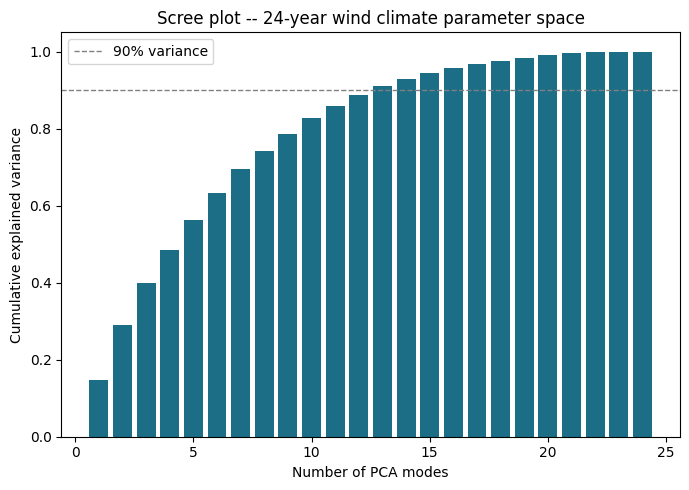

Modes needed for 90% variance: 13 (of 24 possible)


In [4]:
COL_MEAN = REAL_MATRIX.mean(axis=0)
COL_STD = REAL_MATRIX.std(axis=0)
STD_MATRIX = (REAL_MATRIX - COL_MEAN) / COL_STD

U, S, Vt = np.linalg.svd(STD_MATRIX, full_matrices=False)
explained_var = S ** 2 / np.sum(S ** 2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(range(1, len(explained_var) + 1), np.cumsum(explained_var), color="#1B6E86")
ax.axhline(0.9, color="gray", linestyle="--", linewidth=1, label="90% variance")
ax.set_xlabel("Number of PCA modes")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("Scree plot -- 24-year wind climate parameter space")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "pca_scree_plot.png", dpi=180, bbox_inches="tight")
plt.show()

N_MODES = int(np.searchsorted(np.cumsum(explained_var), 0.9) + 1)
print(f"Modes needed for 90% variance: {N_MODES} (of {len(explained_var)} possible)")

## 4. Sampling synthetic roses

In PCA space the mode scores are independent, each with variance equal to its own eigenvalue -- so a synthetic draw is just independent normal samples per mode, scaled by `S`, reconstructed back into freq/A/k, then clipped to stay physical (frequencies non-negative and renormalized to sum to 1; A and k kept positive). `extreme_modes` optionally restricts the `scale` multiplier to only the strongest modes (PC1, PC2, ...), leaving the weaker/noisier modes at their natural size -- see 5 for why.

In [5]:
def sample_synthetic_row(rng, n_modes=N_MODES, scale=1.0, extreme_modes=None):
    scale_vec = np.full(n_modes, scale if extreme_modes is None else 1.0)
    if extreme_modes is not None:
        scale_vec[:extreme_modes] = scale

    scores = rng.normal(0, 1, size=n_modes) * scale_vec * S[:n_modes] / np.sqrt(len(REAL_MATRIX) - 1)
    std_row = scores @ Vt[:n_modes]
    row = std_row * COL_STD + COL_MEAN

    freq, A, k = row[:12], row[12:24], row[24:36]
    freq = np.clip(freq, 1e-4, None)
    freq = freq / freq.sum()
    A = np.clip(A, 0.5, None)
    k = np.clip(k, 0.3, None)
    return np.concatenate([freq, A, k])

def sample_synthetic_site(rng, n_modes=N_MODES, scale=1.0, extreme_modes=None, ti=TI):
    row = sample_synthetic_row(rng, n_modes=n_modes, scale=scale, extreme_modes=extreme_modes)
    freq, A, k = row[:12], row[12:24], row[24:36]
    return UniformWeibullSite(p_wd=list(freq), a=list(A), k=list(k), ti=ti)

## 5. Normal vs. extreme synthetic roses

`scale=1` draws stay inside the range the 24 real years already show.

For "extreme", pushing *all* 13 modes to 3x their natural spread at once compounds into combinations no real year ever showed even loosely -- modes 4-13 are individually weak/noisy, and randomly maxing out all of them together can rotate the dominant direction to somewhere the real 24-year record never points to, which stops looking like "an extreme version of Vineyard's climate" and starts looking like an unrelated location. Instead, `extreme_modes=3` pushes only PC1-PC3 -- the strongest, most physically real patterns -- to `scale=3`, and leaves the weaker modes at their natural size. That keeps the extreme draw anchored to Vineyard's own dominant modes of variability, just pushed hard along them, closer to how a genuinely unusual real year would behave (a large coherent shift, not thirteen simultaneous independent ones).

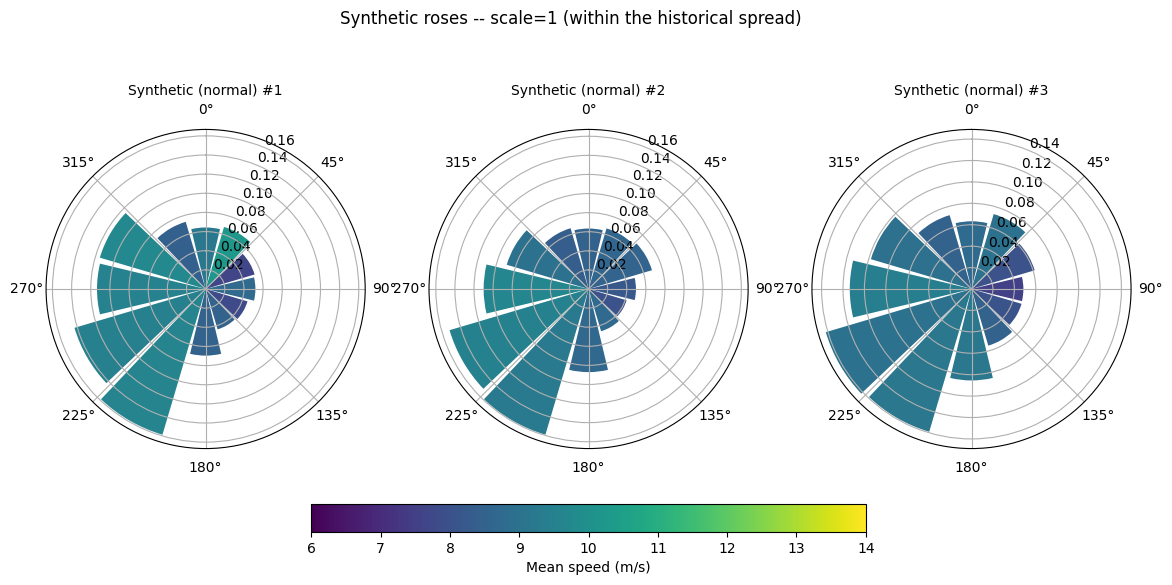

In [6]:
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 3, figsize=(14, 6), subplot_kw={"projection": "polar"})
for i, ax in enumerate(axes):
    row = sample_synthetic_row(rng, scale=1.0)
    plot_rose(ax, row, f"Synthetic (normal) #{i+1}")
add_speed_colorbar(fig, axes)
fig.suptitle("Synthetic roses -- scale=1 (within the historical spread)")
fig.savefig(FIGURES_DIR / "synthetic_roses_normal.png", dpi=180, bbox_inches="tight")
plt.show()

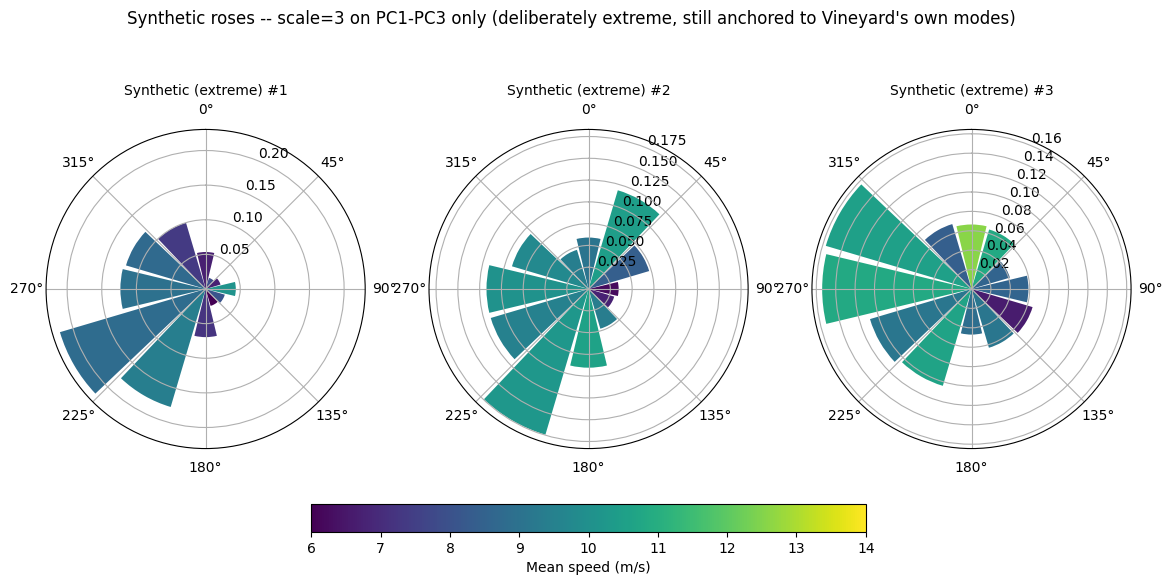

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6), subplot_kw={"projection": "polar"})
for i, ax in enumerate(axes):
    row = sample_synthetic_row(rng, scale=3.0, extreme_modes=3)
    plot_rose(ax, row, f"Synthetic (extreme) #{i+1}")
add_speed_colorbar(fig, axes)
fig.suptitle("Synthetic roses -- scale=3 on PC1-PC3 only (deliberately extreme, still anchored to Vineyard's own modes)")
fig.savefig(FIGURES_DIR / "synthetic_roses_extreme.png", dpi=180, bbox_inches="tight")
plt.show()

### 5.1 Complementary view -- all roses overlaid

Same information as the panels above, but as outlines on one shared polar axis: the real mean (thick, the rose already in `energy_resource_us.yaml`), several `scale=1` draws (thin, transparent), and two `scale=3` draws highlighted. Overlaying makes the extreme cases' departure from the mean shape directly visible, instead of comparing separate panels by eye.

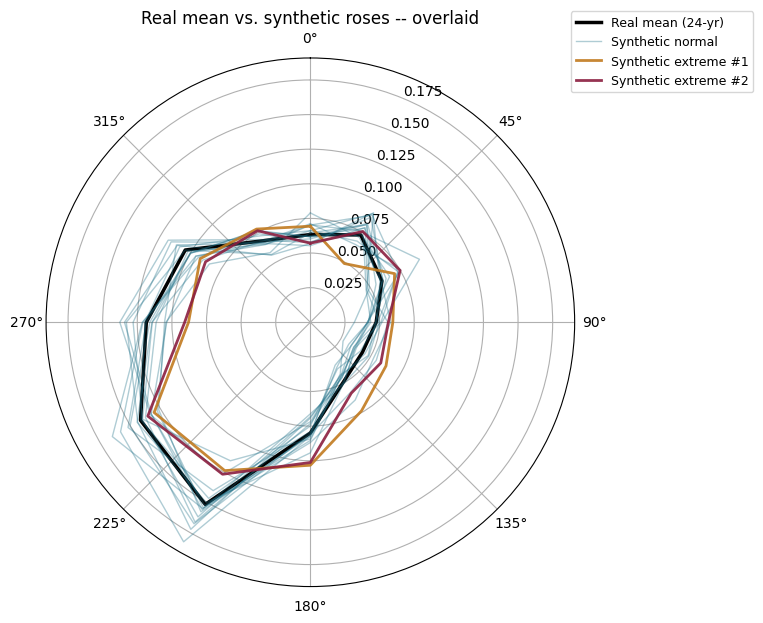

In [8]:
def rose_outline(ax, row, color, lw, alpha, label=None):
    freq, _ = rose_from_row(row)
    theta = np.radians(np.append(SECTOR_DEG, 360))
    r = np.append(freq, freq[0])
    ax.plot(theta, r, color=color, linewidth=lw, alpha=alpha, label=label)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

mean_row = np.concatenate([COL_MEAN[:12] / COL_MEAN[:12].sum(), COL_MEAN[12:24], COL_MEAN[24:36]])
rose_outline(ax, mean_row, "black", 2.5, 1.0, label="Real mean (24-yr)")

for i in range(15):
    rose_outline(ax, sample_synthetic_row(rng, scale=1.0), "#1B6E86", 1, 0.35,
                 label="Synthetic normal" if i == 0 else None)

for i, color in enumerate(["#C17A1F", "#8B1E3F"]):
    rose_outline(ax, sample_synthetic_row(rng, scale=3.0, extreme_modes=3), color, 2, 0.9, label=f"Synthetic extreme #{i+1}")

ax.set_title("Real mean vs. synthetic roses -- overlaid")
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "roses_overlay_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Validation -- synthetic spread vs. real spread

200 `scale=1` synthetic draws, compared against the 24 real years on two summary statistics: overall mean wind speed and the frequency of the dominant sector. The synthetic cloud should surround the real points, not sit off to one side of them.

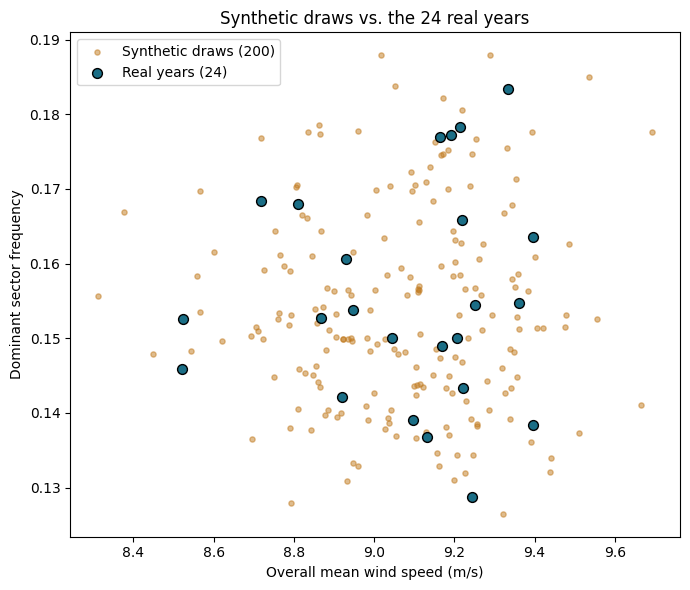

In [9]:
def summary_stats(row):
    freq, mean_speed = rose_from_row(row)
    overall_mean_speed = np.sum(freq * mean_speed)
    dominant_freq = freq.max()
    return overall_mean_speed, dominant_freq

real_stats = np.array([summary_stats(row) for row in REAL_MATRIX])
synthetic_stats = np.array([summary_stats(sample_synthetic_row(rng, scale=1.0)) for _ in range(200)])

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(synthetic_stats[:, 0], synthetic_stats[:, 1], s=14, color="#C17A1F", alpha=0.5, label="Synthetic draws (200)")
ax.scatter(real_stats[:, 0], real_stats[:, 1], s=50, color="#1B6E86", edgecolor="black", label="Real years (24)")
ax.set_xlabel("Overall mean wind speed (m/s)")
ax.set_ylabel("Dominant sector frequency")
ax.set_title("Synthetic draws vs. the 24 real years")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "validation_synthetic_vs_real.png", dpi=180, bbox_inches="tight")
plt.show()

### 6.1 Performance Index -- reconstruction fidelity

Same validation style as Skittides, C.; Fruh, W.-G. **"A new Measure-Correlate-Predict Wind Resource Prediction method."** ICREPQ'15, La Coruna, Spain, 2015: compare the actual and predicted wind speed *distributions* (1 m/s bins), take the total absolute error between them, and express it as a **Performance Index** relative to a baseline. Their baseline was linear-regression MCP; ours is the flat 24-year mean rose (i.e., the single fixed climate the old pipeline effectively assumed everywhere).

For each real year, this projects that year into the truncated `N_MODES`-dimension PCA space and reconstructs it back -- exactly the compression the emulator performs when sampling -- and checks whether the reconstructed distribution still resembles that year's real distribution better than just assuming the flat mean. `PI < 1` means the truncated PCA model keeps real year-to-year information; `PI` close to 1 means truncation threw away too much and the emulator is no better than a single fixed climate.

In [10]:
WS_BINS = np.arange(0.5, 30.5, 1.0)

def marginal_speed_pdf(row, ws_bins=WS_BINS):
    freq, A, k = row[:12], row[12:24], row[24:36]
    pdf = np.zeros_like(ws_bins)
    for f, a, kk in zip(freq, A, k):
        pdf += f * (kk / a) * (ws_bins / a) ** (kk - 1) * np.exp(-(ws_bins / a) ** kk)
    return pdf / pdf.sum()

def reconstruct_row(row, n_modes=N_MODES):
    std_row = (row - COL_MEAN) / COL_STD
    scores = std_row @ Vt[:n_modes].T
    std_recon = scores @ Vt[:n_modes]
    return std_recon * COL_STD + COL_MEAN

flat_pdf = marginal_speed_pdf(COL_MEAN)

errors_pca, errors_flat = [], []
for row in REAL_MATRIX:
    actual_pdf = marginal_speed_pdf(row)
    recon_pdf = marginal_speed_pdf(reconstruct_row(row))
    errors_pca.append(np.sum(np.abs(actual_pdf - recon_pdf)))
    errors_flat.append(np.sum(np.abs(actual_pdf - flat_pdf)))

errors_pca = np.array(errors_pca)
errors_flat = np.array(errors_flat)
performance_index = errors_pca / errors_flat
print(f"Performance Index: mean={performance_index.mean():.2f}, median={np.median(performance_index):.2f}")

Performance Index: mean=0.20, median=0.15


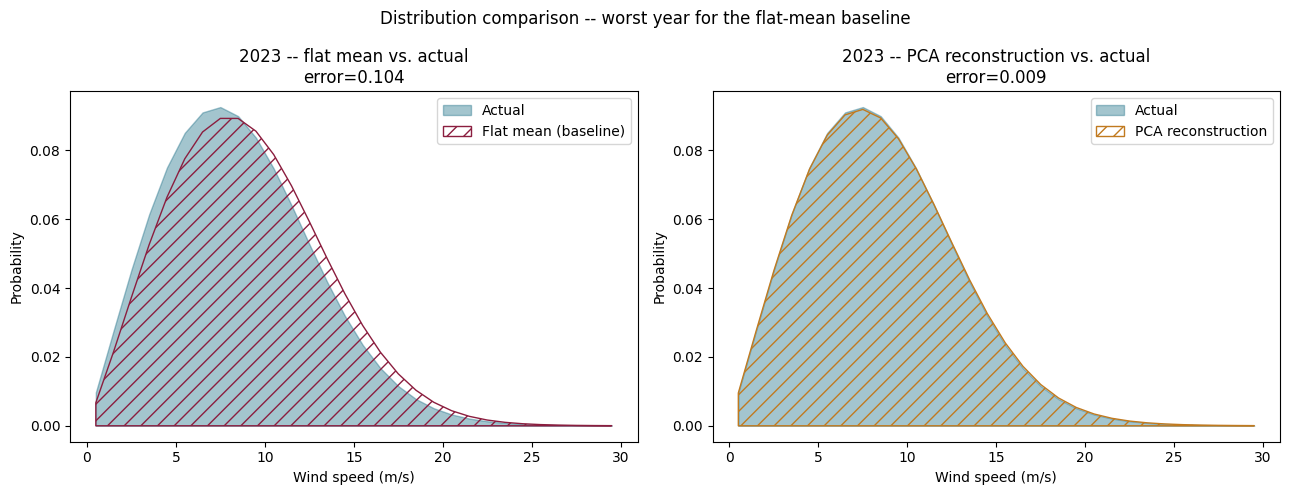

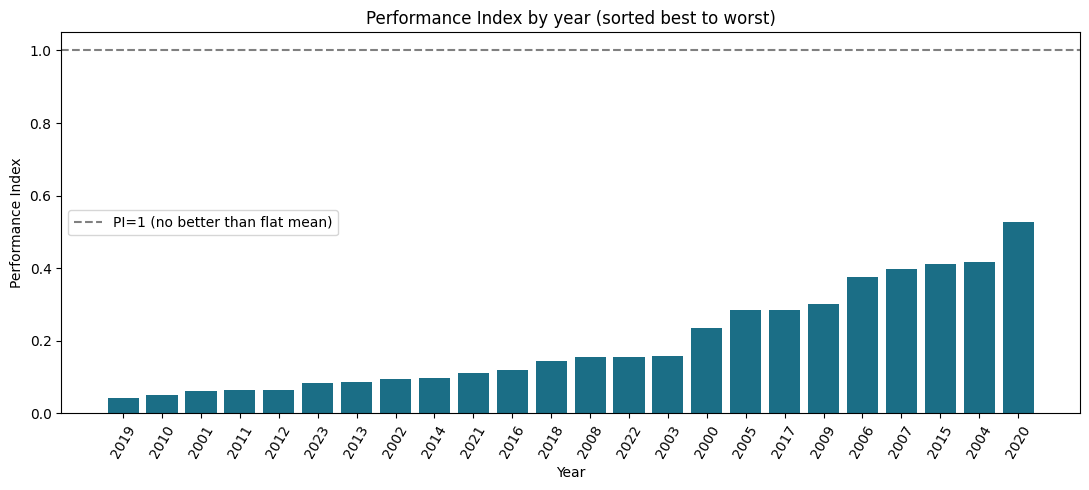

In [11]:
example = np.argmax(errors_flat)  # the year the flat baseline struggles with most
actual_pdf = marginal_speed_pdf(REAL_MATRIX[example])
recon_pdf = marginal_speed_pdf(reconstruct_row(REAL_MATRIX[example]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].fill_between(WS_BINS, actual_pdf, color="#1B6E86", alpha=0.4, label="Actual")
axes[0].fill_between(WS_BINS, flat_pdf, color="none", edgecolor="#8B1E3F", hatch="//", label="Flat mean (baseline)")
axes[0].set_title(f"{YEARS[example]} -- flat mean vs. actual\nerror={errors_flat[example]:.3f}")

axes[1].fill_between(WS_BINS, actual_pdf, color="#1B6E86", alpha=0.4, label="Actual")
axes[1].fill_between(WS_BINS, recon_pdf, color="none", edgecolor="#C17A1F", hatch="//", label="PCA reconstruction")
axes[1].set_title(f"{YEARS[example]} -- PCA reconstruction vs. actual\nerror={errors_pca[example]:.3f}")

for ax in axes:
    ax.set_xlabel("Wind speed (m/s)")
    ax.set_ylabel("Probability")
    ax.legend()
fig.suptitle("Distribution comparison -- worst year for the flat-mean baseline")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "performance_index_example_year.png", dpi=180, bbox_inches="tight")
plt.show()

order = np.argsort(performance_index)
years_sorted = [YEARS[i] for i in order]
pi_sorted = performance_index[order]

fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#1B6E86" if pi < 1 else "#8B1E3F" for pi in pi_sorted]
ax.bar(years_sorted, pi_sorted, color=colors)
ax.axhline(1.0, color="gray", linestyle="--", label="PI=1 (no better than flat mean)")
ax.set_xlabel("Year")
ax.set_ylabel("Performance Index")
ax.set_title("Performance Index by year (sorted best to worst)")
ax.tick_params(axis="x", rotation=60)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "performance_index_by_year.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. Old vs. new: 24 fixed points vs. a continuous cloud

Same comparison, now directly in PCA space (first two modes). The 24 real years are what the old pipeline could ever draw; the cloud is everything the emulator can now generate.

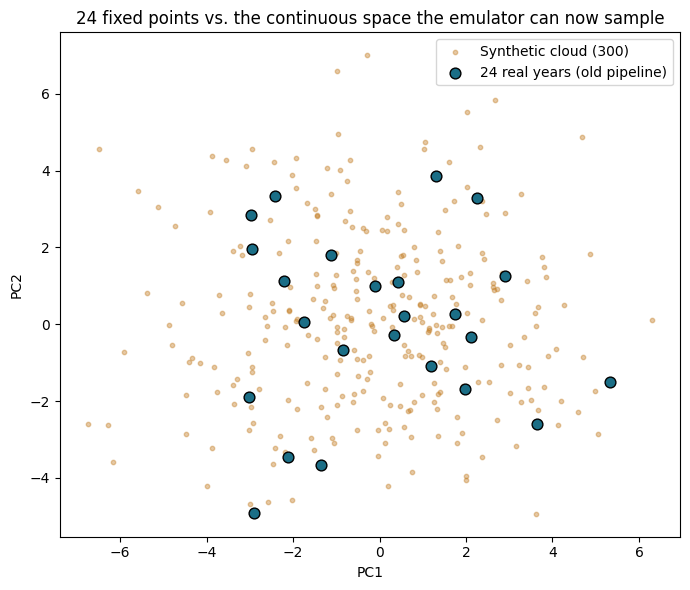

In [12]:
real_scores = STD_MATRIX @ Vt[:2].T
synthetic_scores = np.array([
    (rng.normal(0, 1, size=N_MODES) * S[:N_MODES] / np.sqrt(len(REAL_MATRIX) - 1))[:2]
    for _ in range(300)
])

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(synthetic_scores[:, 0], synthetic_scores[:, 1], s=10, color="#C17A1F", alpha=0.4, label="Synthetic cloud (300)")
ax.scatter(real_scores[:, 0], real_scores[:, 1], s=60, color="#1B6E86", edgecolor="black", label="24 real years (old pipeline)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("24 fixed points vs. the continuous space the emulator can now sample")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "old_vs_new_pca_space.png", dpi=180, bbox_inches="tight")
plt.show()